# Metodologia

![Metodologia](./image/metodologia.jpg)

In [1]:
import numpy as _np
import pandas as _pd
import seaborn as _sns
import basedosdados as _bd
import matplotlib.pyplot as _plt

from dotenv import dotenv_values as _dotenv_values


In [2]:
variables = _dotenv_values("./.env")


In [3]:
_pd.set_option("display.max_columns", None)


In [4]:
billing_id = variables["BILLING_ID"] or "<adicionar seu código de projeto do google cloud>"


In [5]:
query = f"""--sql
    WITH dicionario_categoria AS (
        SELECT
            chave chave_categoria
            , valor descricao_categoria
        FROM `basedosdados.br_me_caged.dicionario`
        WHERE TRUE
            AND nome_coluna = 'categoria'
            AND id_tabela = 'microdados_movimentacao'
    ),
    dicionario_grau_instrucao AS (
        SELECT
            chave chave_grau_instrucao
            , valor descricao_grau_instrucao
        FROM `basedosdados.br_me_caged.dicionario`
        WHERE TRUE
            AND nome_coluna = 'grau_instrucao'
            AND id_tabela = 'microdados_movimentacao'
    ),
    dicionario_raca_cor AS (
        SELECT
            chave chave_raca_cor
            , valor descricao_raca_cor
        FROM `basedosdados.br_me_caged.dicionario`
        WHERE TRUE
            AND nome_coluna = 'raca_cor'
            AND id_tabela = 'microdados_movimentacao'
    ),
    dicionario_sexo AS (
        SELECT
            chave chave_sexo
            , valor descricao_sexo
        FROM `basedosdados.br_me_caged.dicionario`
        WHERE TRUE
            AND nome_coluna = 'sexo'
            AND id_tabela = 'microdados_movimentacao'
    ),
    dicionario_tipo_empregador AS (
        SELECT
            chave chave_tipo_empregador
            , valor descricao_tipo_empregador
        FROM `basedosdados.br_me_caged.dicionario`
        WHERE TRUE
            AND nome_coluna = 'tipo_empregador'
            AND id_tabela = 'microdados_movimentacao'
    ),
    dicionario_tipo_estabelecimento AS (
        SELECT
            chave chave_tipo_estabelecimento
            , valor descricao_tipo_estabelecimento
        FROM `basedosdados.br_me_caged.dicionario`
        WHERE TRUE
            AND nome_coluna = 'tipo_estabelecimento'
            AND id_tabela = 'microdados_movimentacao'
    ),
    dicionario_tipo_movimentacao AS (
        SELECT
            chave chave_tipo_movimentacao
            , valor descricao_tipo_movimentacao
        FROM `basedosdados.br_me_caged.dicionario`
        WHERE TRUE
            AND nome_coluna = 'tipo_movimentacao'
            AND id_tabela = 'microdados_movimentacao'
    ),
    dicionario_tipo_deficiencia AS (
        SELECT
            chave chave_tipo_deficiencia
            , valor descricao_tipo_deficiencia
        FROM `basedosdados.br_me_caged.dicionario`
        WHERE TRUE
            AND nome_coluna = 'tipo_deficiencia'
            AND id_tabela = 'microdados_movimentacao'
    ),
    dicionario_indicador_trabalho_intermitente AS (
        SELECT
            chave chave_indicador_trabalho_intermitente
            , valor descricao_indicador_trabalho_intermitente
        FROM `basedosdados.br_me_caged.dicionario`
        WHERE TRUE
            AND nome_coluna = 'indicador_trabalho_intermitente'
            AND id_tabela = 'microdados_movimentacao'
    ),
    dicionario_indicador_trabalho_parcial AS (
        SELECT
            chave chave_indicador_trabalho_parcial
            , valor descricao_indicador_trabalho_parcial
        FROM `basedosdados.br_me_caged.dicionario`
        WHERE TRUE
            AND nome_coluna = 'indicador_trabalho_parcial'
            AND id_tabela = 'microdados_movimentacao'
    ),
    dicionario_indicador_aprendiz AS (
        SELECT
            chave chave_indicador_aprendiz
            , valor descricao_indicador_aprendiz
        FROM `basedosdados.br_me_caged.dicionario`
        WHERE TRUE
            AND nome_coluna = 'indicador_aprendiz'
            AND id_tabela = 'microdados_movimentacao'
    ),
    dicionario_origem_informacao AS (
        SELECT
            chave chave_origem_informacao
            , valor descricao_origem_informacao
        FROM `basedosdados.br_me_caged.dicionario`
        WHERE TRUE
            AND nome_coluna = 'origem_informacao'
            AND id_tabela = 'microdados_movimentacao'
    )
    SELECT
        'RU: 4819068' ru
        , dados.ano ano
        , dados.mes mes
        , dados.sigla_uf sigla_uf
        , diretorio_sigla_uf.nome sigla_uf_nome
        , dados.id_municipio id_municipio
        , diretorio_id_municipio.nome id_municipio_nome
        , dados.cnae_2_secao cnae_2_secao
        , dados.cnae_2_subclasse cnae_2_subclasse
        , dados.saldo_movimentacao saldo_movimentacao
        , dados.cbo_2002 cbo_2002
        , diretorio_cbo_2002.descricao cbo_2002_descricao
        , diretorio_cbo_2002.descricao_familia cbo_2002_descricao_familia
        , diretorio_cbo_2002.descricao_subgrupo cbo_2002_descricao_subgrupo
        , diretorio_cbo_2002.descricao_subgrupo_principal cbo_2002_descricao_subgrupo_principal
        , diretorio_cbo_2002.descricao_grande_grupo cbo_2002_descricao_grande_grupo
        , descricao_categoria categoria
        , descricao_grau_instrucao grau_instrucao
        , dados.idade idade
        , dados.horas_contratuais horas_contratuais
        , descricao_raca_cor raca_cor
        , descricao_sexo sexo
        , descricao_tipo_empregador tipo_empregador
        , descricao_tipo_estabelecimento tipo_estabelecimento
        , descricao_tipo_movimentacao tipo_movimentacao
        , descricao_tipo_deficiencia tipo_deficiencia
        , descricao_indicador_trabalho_intermitente indicador_trabalho_intermitente
        , descricao_indicador_trabalho_parcial indicador_trabalho_parcial
        , dados.salario_mensal salario_mensal
        , dados.tamanho_estabelecimento_janeiro tamanho_estabelecimento_janeiro
        , descricao_indicador_aprendiz indicador_aprendiz
        , descricao_origem_informacao origem_informacao
        , dados.indicador_fora_prazo indicador_fora_prazo
    FROM `basedosdados.br_me_caged.microdados_movimentacao` dados
    LEFT JOIN (
        SELECT DISTINCT
            sigla
            , nome
        FROM `basedosdados.br_bd_diretorios_brasil.uf`
    ) diretorio_sigla_uf
        ON dados.sigla_uf = diretorio_sigla_uf.sigla
    LEFT JOIN (
        SELECT DISTINCT
            id_municipio
            , nome
        FROM `basedosdados.br_bd_diretorios_brasil.municipio`
    ) diretorio_id_municipio
        ON dados.id_municipio = diretorio_id_municipio.id_municipio
    LEFT JOIN (
        SELECT DISTINCT
            cbo_2002
            , descricao
            , descricao_familia
            , descricao_subgrupo
            , descricao_subgrupo_principal
            , descricao_grande_grupo
        FROM `basedosdados.br_bd_diretorios_brasil.cbo_2002`
    ) diretorio_cbo_2002
        ON dados.cbo_2002 = diretorio_cbo_2002.cbo_2002
    LEFT JOIN `dicionario_categoria`
        ON dados.categoria = chave_categoria
    LEFT JOIN `dicionario_grau_instrucao`
        ON dados.grau_instrucao = chave_grau_instrucao
    LEFT JOIN `dicionario_raca_cor`
        ON dados.raca_cor = chave_raca_cor
    LEFT JOIN `dicionario_sexo`
        ON dados.sexo = chave_sexo
    LEFT JOIN `dicionario_tipo_empregador`
        ON dados.tipo_empregador = chave_tipo_empregador
    LEFT JOIN `dicionario_tipo_estabelecimento`
        ON dados.tipo_estabelecimento = chave_tipo_estabelecimento
    LEFT JOIN `dicionario_tipo_movimentacao`
        ON dados.tipo_movimentacao = chave_tipo_movimentacao
    LEFT JOIN `dicionario_tipo_deficiencia`
        ON dados.tipo_deficiencia = chave_tipo_deficiencia
    LEFT JOIN `dicionario_indicador_trabalho_intermitente`
        ON dados.indicador_trabalho_intermitente = chave_indicador_trabalho_intermitente
    LEFT JOIN `dicionario_indicador_trabalho_parcial`
        ON dados.indicador_trabalho_parcial = chave_indicador_trabalho_parcial
    LEFT JOIN `dicionario_indicador_aprendiz`
        ON dados.indicador_aprendiz = chave_indicador_aprendiz
    LEFT JOIN `dicionario_origem_informacao`
        ON dados.origem_informacao = chave_origem_informacao
    WHERE TRUE
        AND dados.id_municipio = '3203205'
        AND dados.ano = 2024
;"""[5:-1]


In [6]:
df = _bd.read_sql(query, billing_id)


Downloading: 100%|██████████|


In [7]:
# Definição dos tipos
df = df.astype({k: "string" for k, v in df.dtypes.items() if v == "object"})

# Normalização de salários (deixar mais real)
df["salario_mensal"] = df["salario_mensal"].clip(lower=1518)


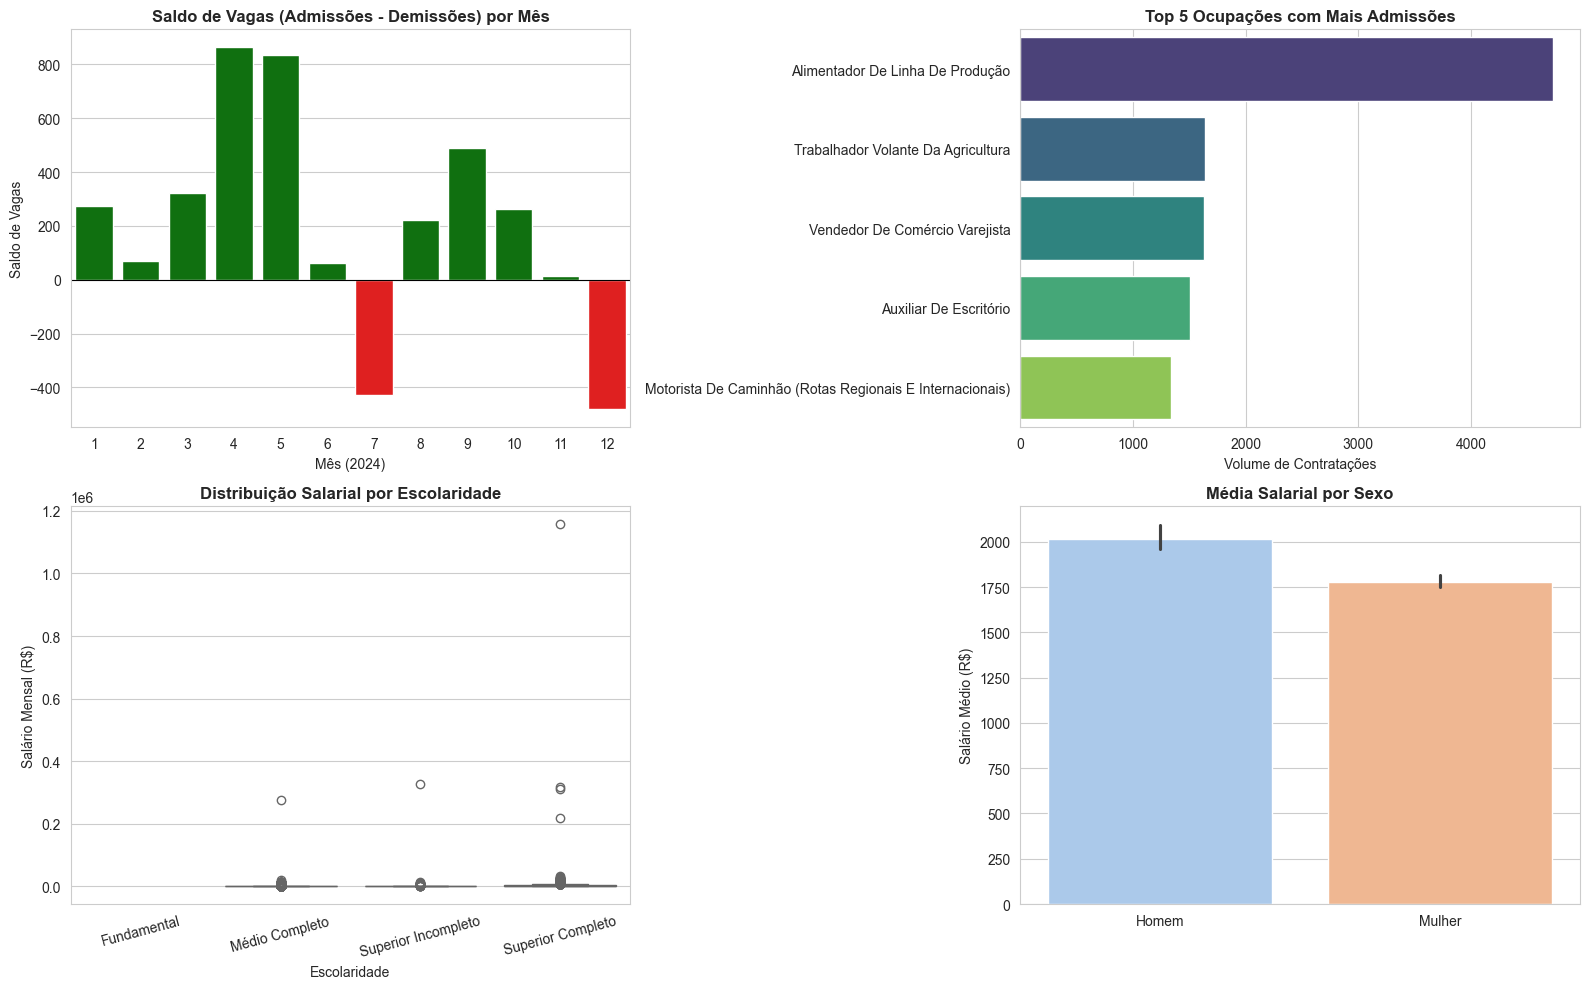

In [8]:
# CONFIGURAÇÃO DO DASHBOARD
_sns.set_style("whitegrid")
fig, axes = _plt.subplots(2, 2, figsize=(16, 10))
_plt.subplots_adjust(hspace=0.4, wspace=0.3)

# --- GRÁFICO 1: Saldo de Movimentação por Mês (Sazonalidade) ---
# Calcula o saldo (soma de 1 e -1)
saldo_mensal = df.groupby("mes")["saldo_movimentacao"].sum().reset_index()
colors_saldo = ["red" if x < 0 else "green" for x in saldo_mensal["saldo_movimentacao"]]

_sns.barplot(data=saldo_mensal, x="mes", y="saldo_movimentacao", ax=axes[0, 0], palette=colors_saldo)
axes[0, 0].set_title("Saldo de Vagas (Admissões - Demissões) por Mês", fontsize=12, fontweight="bold")
axes[0, 0].set_ylabel("Saldo de Vagas")
axes[0, 0].set_xlabel("Mês (2024)")
axes[0, 0].axhline(0, color="black", linewidth=0.8)

# --- GRÁFICO 2: Top Profissões com Maior Movimentação (Admissão) ---
# Filtra apenas admissões para ver o que está "quente"
admissoes = df[df["saldo_movimentacao"] == 1]
top_cargos = admissoes["cbo_2002_descricao"].value_counts().head(5).reset_index()
top_cargos.columns = ["Cargo", "Admissões"]

_sns.barplot(data=top_cargos, y="Cargo", x="Admissões", ax=axes[0, 1], palette="viridis")
axes[0, 1].set_title("Top 5 Ocupações com Mais Admissões", fontsize=12, fontweight="bold")
axes[0, 1].set_xlabel("Volume de Contratações")
axes[0, 1].set_ylabel("")

# --- GRÁFICO 3: Distribuição de Salários por Grau de Instrução (Boxplot) ---
# Mostra a dispersão e a mediana
_sns.boxplot(data=df, x="grau_instrucao", y="salario_mensal", ax=axes[1, 0], palette="coolwarm",
            order=["Fundamental", "Médio Completo", "Superior Incompleto", "Superior Completo"])
axes[1, 0].set_title("Distribuição Salarial por Escolaridade", fontsize=12, fontweight="bold")
axes[1, 0].set_ylabel("Salário Mensal (R$)")
axes[1, 0].set_xlabel("Escolaridade")
axes[1, 0].tick_params(axis="x", rotation=15)

# --- GRÁFICO 4: Média Salarial por Sexo (Barplot com erro) ---
_sns.barplot(data=df, x="sexo", y="salario_mensal", ax=axes[1, 1], estimator=_np.mean, palette="pastel")
axes[1, 1].set_title("Média Salarial por Sexo", fontsize=12, fontweight="bold")
axes[1, 1].set_ylabel("Salário Médio (R$)")
axes[1, 1].set_xlabel("")

_plt.tight_layout()
_plt.savefig("./image/analise_caged_linhares.png")
_plt.show()


In [9]:
# Oferta de Cursos (Mapeamento IFES, SENAI, SENAC, CETEC)
# Lista de cursos encontrados nas instituições locais
oferta_cursos = {
    "Agropecuária": ["Manutenção Máq. Agrícolas (SENAI)"],
    "Indústria/Operacional": ["Mecânica", "Eletrotécnica", "Automação", "Soldagem", "NRs", "Logística"],
    "Comércio/Vendas": ["Vendas (SENAC)", "Gestão", "Faturamento (QualificarES)"],
    "Administrativo": ["Téc. Administração (IFES)", "RH", "Assist. Admin"],
    "Saúde": ["Téc. Enfermagem (CETEC)", "Balconista Farmácia", "Cuidador"],
    "Tecnologia (TI)": ["Suporte (IFES)", "Programador (Microlins)", "Informática"]
}


In [10]:
df_demanda_mercado = (
    df.groupby(["cbo_2002_descricao"])["saldo_movimentacao"]
    .sum()
    .reset_index()
    .query("saldo_movimentacao < 0")
    .rename(columns={"saldo_movimentacao": "contagem_vagas"})
    .assign(contagem_vagas=lambda df: df["contagem_vagas"].abs())
)


In [11]:
idx_agropecuaria = df_demanda_mercado.pipe(lambda df: df[df["cbo_2002_descricao"].str.match(r".*agropecuári.*", False)]).index
idx_industria_operacional = df_demanda_mercado.pipe(lambda df: df[df["cbo_2002_descricao"].str.match(r".*industria.*|.*operacional.*", False)]).index
idx_comercial_vendas = df_demanda_mercado.pipe(lambda df: df[df["cbo_2002_descricao"].str.match(r".*comerci.*|.*comérci.*|.*vend.*", False)]).index
idx_administrativo = df_demanda_mercado.pipe(lambda df: df[df["cbo_2002_descricao"].str.match(r".*administrativ.*", False)]).index
idx_saude = df_demanda_mercado.pipe(lambda df: df[df["cbo_2002_descricao"].str.match(r".*saúde.*", False)]).index
idx_tecnologia = df_demanda_mercado.pipe(lambda df: df[df["cbo_2002_descricao"].str.match(r".*tecnologi.*", False)]).index

df_demanda_mercado.loc[idx_agropecuaria, "cbo_2002_descricao"] = "Agropecuária"
df_demanda_mercado.loc[idx_industria_operacional, "cbo_2002_descricao"] = "Indústria/Operacional"
df_demanda_mercado.loc[idx_comercial_vendas, "cbo_2002_descricao"] = "Comércio/Vendas"
df_demanda_mercado.loc[idx_administrativo, "cbo_2002_descricao"] = "Administrativo"
df_demanda_mercado.loc[idx_saude, "cbo_2002_descricao"] = "Saúde"
df_demanda_mercado.loc[idx_tecnologia, "cbo_2002_descricao"] = "Tecnologia (TI)"


In [12]:
demandas_mercado = df_demanda_mercado[df_demanda_mercado["cbo_2002_descricao"].isin([
    "Agropecuária",
    "Indústria/Operacional",
    "Comércio/Vendas",
    "Administrativo",
    "Saúde",
    "Tecnologia (TI)",
])].groupby("cbo_2002_descricao").sum().to_dict("dict")["contagem_vagas"]


In [13]:
categorias = list(demandas_mercado.keys())
score_demanda = [demandas_mercado[cat] for cat in categorias]
qtd_cursos = [len(oferta_cursos[cat]) for cat in categorias]

df_match = _pd.DataFrame({
    "Setor": categorias,
    "Intensidade da Demanda (Vagas)": score_demanda,
    "Qtd. de Cursos Disponíveis": qtd_cursos
})

df_match["Score Cursos (Escala)"] = df_match["Qtd. de Cursos Disponíveis"] * 15


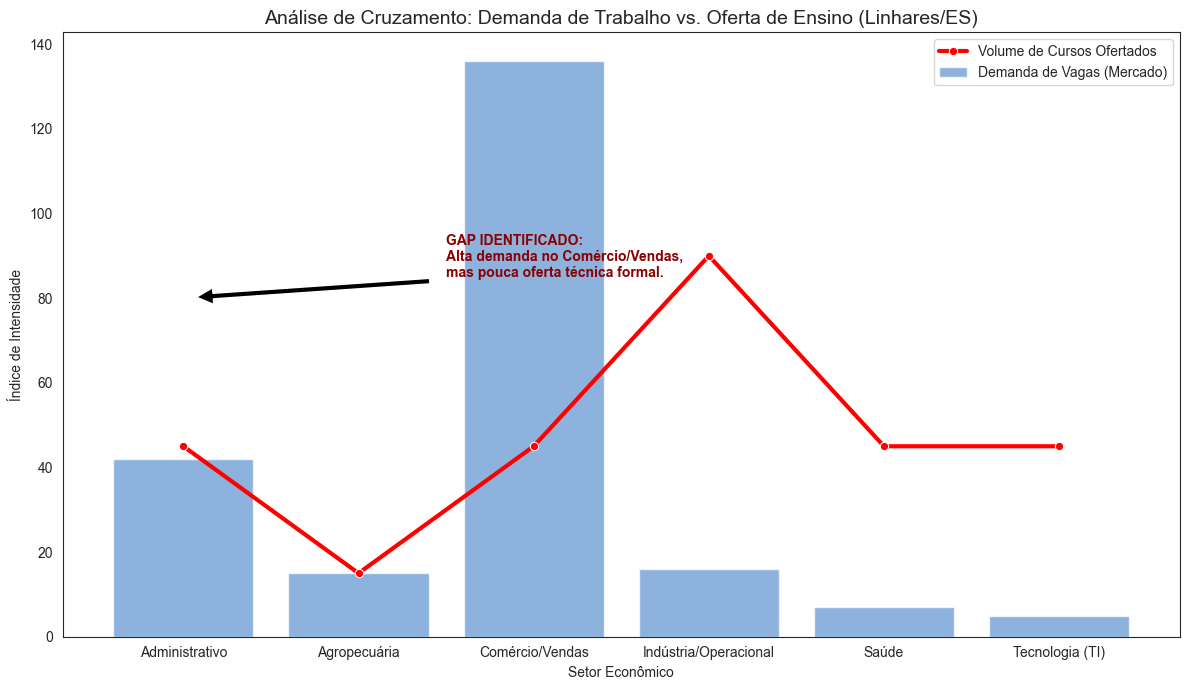

In [ ]:
# --- VISUALIZAÇÃO (GAP ANALYSIS) ---
_plt.figure(figsize=(12, 7))
_sns.set_style("white")

# Plotando a Demanda (Barras Azuis)
bar1 = _sns.barplot(data=df_match, x="Setor", y="Intensidade da Demanda (Vagas)",
            color="#4a90e2", alpha=0.7, label="Demanda de Vagas (Mercado)")

# Plotando a Oferta (Linha Vermelha com Pontos)
_sns.lineplot(data=df_match, x="Setor", y="Score Cursos (Escala)",
             marker="o", color="red", linewidth=3, label="Volume de Cursos Ofertados")

# Ajustes visuais
_plt.title("Análise de Cruzamento: Demanda de Trabalho vs. Oferta de Ensino (Linhares/ES)", fontsize=14)
_plt.ylabel("Índice de Intensidade")
_plt.xlabel("Setor Econômico")
_plt.legend()

# Anotação do Insight
_plt.annotate("GAP IDENTIFICADO:\nAlta demanda no Comércio/Vendas,\nmas pouca oferta técnica formal.",
             xy=(0, 80), xytext=(1.5, 85),
             arrowprops=dict(facecolor="black", shrink=0.05),
             fontsize=10, color="darkred", fontweight="bold")

_plt.tight_layout()
_plt.savefig("./image/grafico_gap_analise.png")
_plt.show()
